# knn predictive modeling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pyplot
import seaborn as sns

## preliminary EDA

88150.94999999998


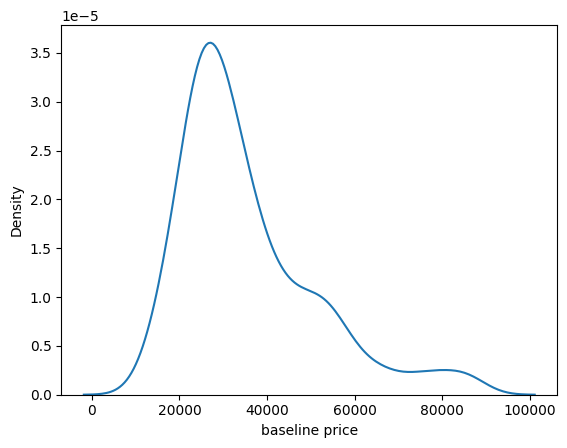

In [2]:
df = pd.read_csv('../data/cars_env.csv')
df.head()

# Drop extremely expensive cars
q90 = np.quantile( df['baseline price'],.9) # Compute the .9 quantile
print(q90)
keep = df['baseline price'] < q90  # Logical condition asserting price < .9 quantile
df = df.loc[keep,:] # Use locator function to filter on a Boolean conditional
df.describe()
sns.kdeplot(data=df,x='baseline price')

# Simplify the vehicle classification scheme
df['class'] = df['EPA class']
df['class'] = df['class'].replace(['MIDSIZE CARS','COMPACT CARS','SUBCOMPACT CARS','TWO SEATERS','LARGE CARS'],'car')
df['class'] = df['class'].replace(['SMALL STATION WAGONS','MIDSIZE STATION WAGONS'],'station wagon')
df['class'] = df['class'].replace(['STANDARD PICKUP TRUCKS','SMALL PICKUP TRUCKS'],'truck')
df['class'] = df['class'].replace(['VANS','MINIVAN'],'van')

baseline price                                            \
                       count          mean           std           min   
class                                                                    
SUV                    156.0  36276.038126  13265.630531  17913.329655   
car                    204.0  39021.420695  18857.153237  11783.040000   
station wagon           20.0  29476.437707  11321.733049  15549.900000   
truck                   71.0  26922.926268   4607.697988  16203.698951   
van                     20.0  27778.296419   3076.716822  21377.160000   

                                                                       
                        25%           50%           75%           max  
class                                                                  
SUV            25774.364884  32711.075180  43136.206482  84377.468696  
car            24223.980000  35267.658110  51016.575000  87490.500000  
station wagon  17602.650000  30156.575074  35414.575625  55870.500000  
truck          23909.662556  26394.033673  30116.107816  37840.535000  
van            25896.296891  28096.389352  29447.920444  34353.600000

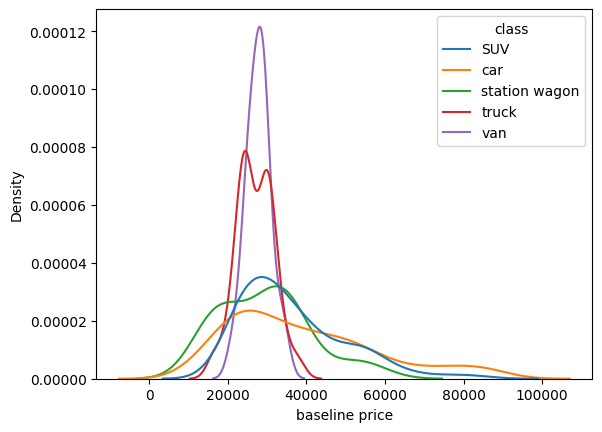

In [3]:
sns.kdeplot(x=df['baseline price'], hue = df['class'], common_norm=False)
df.loc[:,['baseline price','class']].groupby('class').describe() # Baseline price by simplified vehicle class

<Axes: xlabel='footprint', ylabel='Density'>

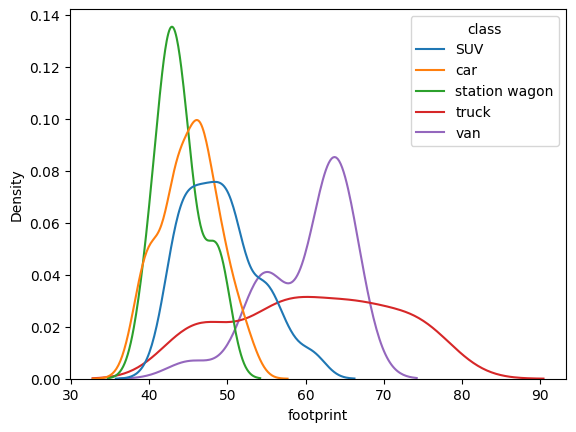

In [4]:
sns.kdeplot(x=df['footprint'], hue=df['class'], common_norm=False)

<Axes: xlabel='footprint', ylabel='baseline price'>

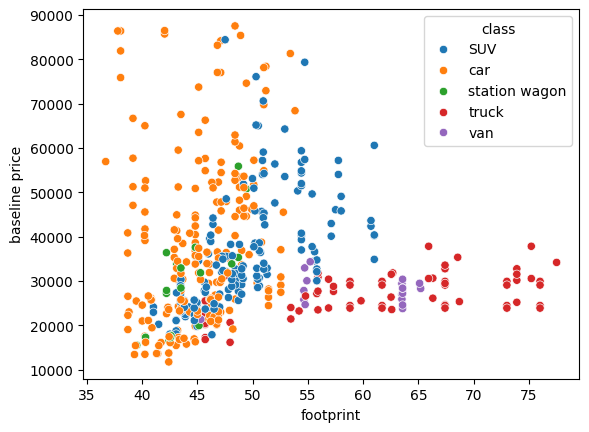

In [5]:
sns.scatterplot(x=df['footprint'], y=df['baseline price'], hue=df['class'])

In [6]:
# normalize the data
y = df['class']
x = df.loc[:,['footprint', 'baseline price']]

def maxminscaler(x):
    xnp = x.to_numpy()
    u = (xnp-min(xnp)) / (max(xnp)-min(xnp))
    return u

u = x.apply(maxminscaler)
u.head()

,footprint,baseline price
0,0.345715,0.448082
1,0.206036,0.301227
2,0.267299,0.477520
3,0.272200,0.309544
4,0.228091,0.233795


<Axes: xlabel='footprint', ylabel='baseline price'>

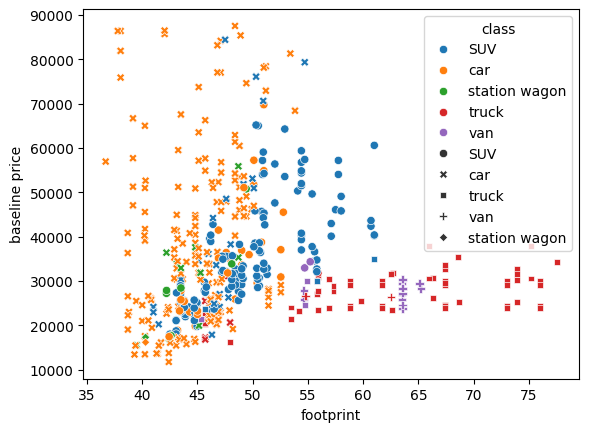

In [7]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model = model.fit(u, y)
yHat = model.predict(u)

# color shows actual classification, shape shows prediction
sns.scatterplot(x=df['footprint'], y=df['baseline price'], hue=y, style=yHat)

## practice

In [8]:
df2 = pd.read_csv('../data/airbnb_NYC.csv', encoding='latin1')
df2.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [9]:
df2['Neighbourhood '].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Bronx', 'Staten Island'],
      dtype=object)

In [10]:
df2.columns

Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='object')

In [11]:
df2.shape

(30478, 13)

In [12]:
df2 = df2.dropna()
df2.shape # 30478 to 22010 rows

(22010, 13)

In [13]:
df2['Price'] = df2['Price'].str.replace(',','').replace('$','')
df2['Price'] = df2['Price'].astype(float)

<Axes: xlabel='Price', ylabel='Review Scores Rating'>

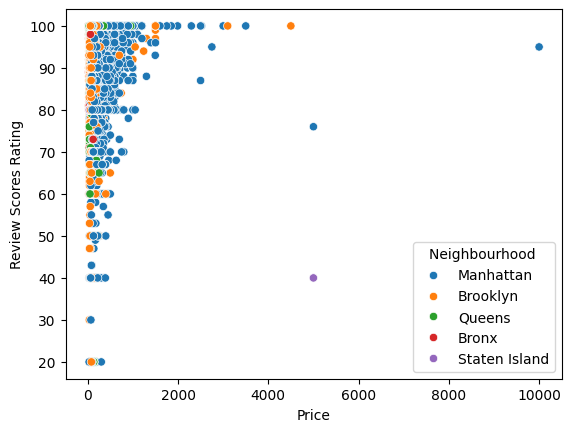

In [14]:
# goal — predict neighbourhood based on score and price
sns.scatterplot(x=df2['Price'], y=df2['Review Scores Rating'], hue=df2['Neighbourhood '])

In [15]:
x2 = df2.loc[:, ['Price', 'Review Scores Rating']]
u2 = x2.apply(maxminscaler)
y2 = df2['Neighbourhood ']

model2 = KNeighborsClassifier(n_neighbors=5)
model2 = model2.fit(u2, y2)
yHat2 = model2.predict(u2)

<Axes: xlabel='Price', ylabel='Review Scores Rating'>

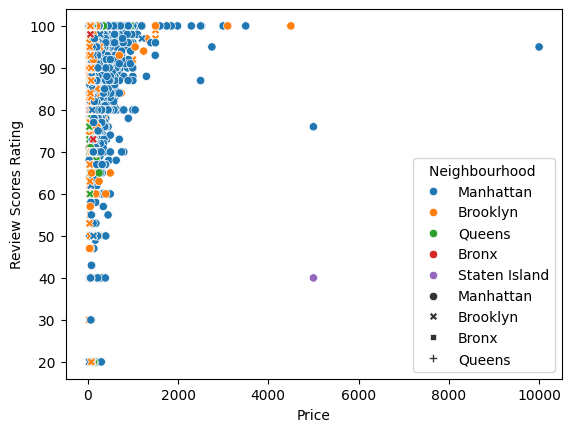

In [16]:
sns.scatterplot(x=df2['Price'], y=df2['Review Scores Rating'], hue=y2, style=yHat2)

In [17]:
pd.crosstab(y2, yHat2)

col_0,Bronx,Brooklyn,Manhattan,Queens
Neighbourhood,,,,
Bronx,19,140,47,9
Brooklyn,14,5522,2840,56
Manhattan,10,4274,7374,35
Queens,2,1070,437,67
Staten Island,0,66,26,2


In [18]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y2, yHat2)

array([[  19,  140,   47,    9,    0],
       [  14, 5522, 2840,   56,    0],
       [  10, 4274, 7374,   35,    0],
       [   2, 1070,  437,   67,    0],
       [   0,   66,   26,    2,    0]])

In [19]:
model2.score(u2, y2)

0.5898228078146297